# NLP Group 08 Project

# NLP-Based Customer Support Ticket Classification System

## Notebook 04: Model Training

**Course:** 7500 - Natural Language Processing  
**Group:** 08

---

## Objective
This notebook trains a machine learning model to classify customer support tickets using the preprocessed dataset.

The model training pipeline includes:

- Loading the preprocessed dataset
- Selecting the text feature and target label
- Splitting the data into training and testing sets
- Converting text into numerical features using TF-IDF
- Training a Naive Bayes classifier
- Evaluating model performance
- Saving the trained model and vectorizer

## Imports

The following libraries are used throughout the model training process.

- **os** – Creates folders and manages file paths.
- **joblib** – Saves and loads trained models.
- **pandas** – Loads and manages the dataset.
- **matplotlib.pyplot** – Creates graphs and confusion matrices.

### Scikit-learn Libraries

- **train_test_split** – Splits the dataset into training and testing sets.
- **TfidfVectorizer** – Converts text into TF-IDF numerical features.
- **CountVectorizer** – Converts text into Bag-of-Words numerical features.
- **MultinomialNB** – Trains the Naive Bayes classification model.
- **accuracy_score** – Measures overall model accuracy.
- **precision_score** – Measures the correctness of positive predictions.
- **recall_score** – Measures how well the model identifies each class.
- **f1_score** – Combines precision and recall into a single score.
- **classification_report** – Displays detailed model performance metrics.
- **ConfusionMatrixDisplay** – Visualizes the confusion matrix.

In [37]:
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

## Load Preprocessed Dataset

In [27]:
import os
import pandas as pd

print("Current working directory:")
print(os.getcwd())

print("\nContents of ../data:")
print(os.listdir("../data"))

# Load dataset
df = pd.read_csv("../data/nlp_dataset_train_pre-processed.csv")

df.head()

Current working directory:
/home/atkinson.p/7500 group project  mu drafts/notebooks

Contents of ../data:
['.ipynb_checkpoints', 'Raw', 'Trained', 'nlp_dataset.parquet', 'nlp_dataset_train_pre-processed.csv']


,Unnamed: 0,Customer Email,Product Purchased,Ticket Type,Ticket Subject,Combined Text,Ticket Priority
0,2794,jessica95@example.com,dell xps,cancellation request,peripheral compatibility,my dell xps is making strange noises and not f...,medium
1,7497,elizabethmeadows@example.com,philips hue lights,cancellation request,delivery problem,m having an issue with the philips hue lights ...,critical
2,7646,foxrichard@example.com,canon dslr camera,billing inquiry,hardware issue,ve forgotten my password for my canon dslr cam...,high
3,2726,christinahicks@example.com,microsoft surface,product inquiry,payment issue,m having an issue with the microsoft surface ...,medium
4,4348,palmersamuel@example.com,iphone,refund request,hardware issue,m having an issue with the iphone please assi...,low


## Check Dataset Structure

In [28]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (6775, 7)

Columns:
['Unnamed: 0', 'Customer Email', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Combined Text', 'Ticket Priority']


## Check Missing Values

In [29]:
df.isnull().sum()

Unnamed: 0           0
Customer Email       0
Product Purchased    0
Ticket Type          0
Ticket Subject       0
Combined Text        0
Ticket Priority      0
dtype: int64

## Select Features and Target

In [30]:
# Select features and target
X = df["Combined Text"].astype(str)
y = df["Ticket Type"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (6775,)
Target shape: (6775,)


## Train/Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5420
Testing samples: 1355


## TF-IDF Feature Extraction

In [32]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (5420, 5000)
Testing TF-IDF shape: (1355, 5000)


## Train TF-IDF Naive Bayes Model

In [33]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Naive Bayes model training complete.")

Naive Bayes model training complete.


## Evaluate Model TF-IDF Naive Bayes Model

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Make predictions
y_pred = model.predict(X_test_tfidf)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.1808
Precision: 0.1790
Recall   : 0.1808
F1 Score : 0.1788

Classification Report:
                      precision    recall  f1-score   support

     billing inquiry       0.15      0.11      0.13       255
cancellation request       0.18      0.18      0.18       274
     product inquiry       0.17      0.17      0.17       265
      refund request       0.21      0.22      0.22       281
     technical issue       0.18      0.21      0.20       280

            accuracy                           0.18      1355
           macro avg       0.18      0.18      0.18      1355
        weighted avg       0.18      0.18      0.18      1355



## TF-IDF Confusion Matrix

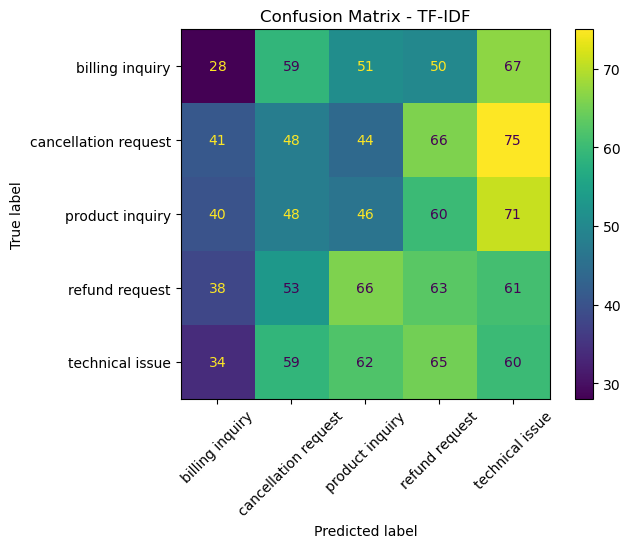

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Confusion Matrix - TF-IDF")
plt.show()

## Bag-of-Words Feature Extraction

In [38]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("Training Shape:", X_train_bow.shape)
print("Testing Shape:", X_test_bow.shape)

Training Shape: (5420, 5000)
Testing Shape: (1355, 5000)


## Train Bag-of-Words Naive Bayes Model

In [39]:
bow_model = MultinomialNB()

bow_model.fit(X_train_bow, y_train)

bow_predictions = bow_model.predict(X_test_bow)

print("Bag-of-Words model training complete.")

Bag-of-Words model training complete.


## Evaluate Bag-of-Words Model

In [40]:
bow_accuracy = accuracy_score(y_test, bow_predictions)
bow_precision = precision_score(y_test, bow_predictions, average="weighted")
bow_recall = recall_score(y_test, bow_predictions, average="weighted")
bow_f1 = f1_score(y_test, bow_predictions, average="weighted")

print(f"Accuracy : {bow_accuracy:.4f}")
print(f"Precision: {bow_precision:.4f}")
print(f"Recall   : {bow_recall:.4f}")
print(f"F1 Score : {bow_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, bow_predictions))

Accuracy : 0.1926
Precision: 0.1901
Recall   : 0.1926
F1 Score : 0.1906

Classification Report

                      precision    recall  f1-score   support

     billing inquiry       0.17      0.13      0.15       255
cancellation request       0.18      0.18      0.18       274
     product inquiry       0.19      0.20      0.19       265
      refund request       0.23      0.27      0.25       281
     technical issue       0.18      0.17      0.18       280

            accuracy                           0.19      1355
           macro avg       0.19      0.19      0.19      1355
        weighted avg       0.19      0.19      0.19      1355



## Bag-of-Words Confusion Matrix

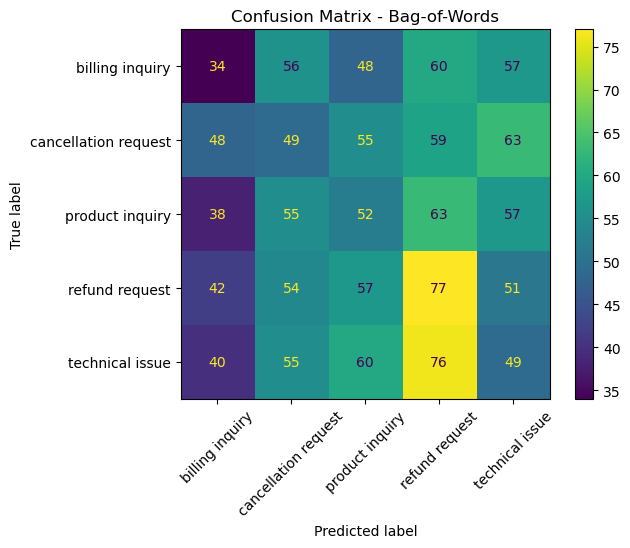

In [41]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    bow_predictions,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Bag-of-Words")
plt.show()

## Model Comparison

In [45]:
comparison_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Naive Bayes"
    ],
    "Feature Representation": [
        "Bag of Words",
        "TF-IDF"
    ],
    "Accuracy": [
        bow_accuracy,
        accuracy
    ],
    "Precision": [
        bow_precision,
        precision
    ],
    "Recall": [
        bow_recall,
        recall
    ],
    "F1 Score": [
        bow_f1,
        f1
    ]
})

comparison_results

,Model,Feature Representation,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,Bag of Words,0.192620,0.190120,0.192620,0.190576
1,Naive Bayes,TF-IDF,0.180812,0.179007,0.180812,0.178801


## Save Model and Vectorizer

In [46]:
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/tfidf_naive_bayes_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

joblib.dump(bow_model, "../models/bow_naive_bayes_model.pkl")
joblib.dump(bow_vectorizer, "../models/bow_vectorizer.pkl")

print("All models and vectorizers saved successfully.")

All models and vectorizers saved successfully.


## Test Prediction

In [47]:
new_ticket = [
    "My package has not arrived and the tracking information has not been updated."
]

# TF-IDF Prediction
tfidf_vector = tfidf.transform(new_ticket)
tfidf_prediction = model.predict(tfidf_vector)

# Bag-of-Words Prediction
bow_vector = bow_vectorizer.transform(new_ticket)
bow_prediction = bow_model.predict(bow_vector)

print("Customer Ticket:")
print(new_ticket[0])

print("\nTF-IDF Prediction:", tfidf_prediction[0])
print("Bag-of-Words Prediction:", bow_prediction[0])

Customer Ticket:
My package has not arrived and the tracking information has not been updated.

TF-IDF Prediction: refund request
Bag-of-Words Prediction: refund request
